# N1 · Maximum likelihood = minimizing KL

> **Status:** ✅ **Complete.** MLE = min forward KL derived; first training loop built and checked against the closed form; the knot NLL$=H(p)+$KL tied numerically; the mode-seeking reverse-KL twin shown. O1, C1.1–C1.3 passed; E1 below = self-check.
>
> Part of the **1D generative-AI curriculum**. New session here? Read `CONTEXT.md` + `ROADMAP.md` first.
>
> **Key component of N1:** the **MLE / forward-KL objective**. In N0 forward KL needed the true `p` (toy-only). Here we show MLE minimizes that *same* forward KL using **only samples** — the exact part of KL that needed `p` is the part that falls away under the optimization. This is the objective almost every model in the course is trained with.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))

import jax, jax.numpy as jnp
from jax import random
import optax
import matplotlib.pyplot as plt

import toylab
from toylab import two_bumps, plot_samples_vs_truth, kl_grid, wasserstein1

# The bag of samples — the ONLY thing the model is allowed to see.
key = random.PRNGKey(0)
N = 2000
data = two_bumps.sample(key, N)

print(f"N = {N} samples drawn from two_bumps (the model never inspects two_bumps itself)")
print(f"sample mean = {jnp.mean(data):.4f}   sample std = {jnp.std(data):.4f}")

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


N = 2000 samples drawn from two_bumps (the model never inspects two_bumps itself)
sample mean = 0.0269   sample std = 2.1302


## 1 · From *grading* a model to *training* one

N0 was a courtroom. We had **two fixed defendants** — `W = N(0, 3)` (over-spread) and `N = N(2, 0.7)` (collapsed) — and we built rulers to *score* them against `two_bumps`. Nobody changed; we only judged.

Training flips the verb. Instead of a couple of fixed models, we take a whole **parametric family** and *search it* for the member closest to the truth. The simplest possible family — the one we'll wear out in this notebook:

$$q_\theta(x) = \mathcal{N}(x;\,\mu,\sigma^2), \qquad \theta = (\mu,\sigma).$$

Two knobs. Turning them sweeps every Gaussian on the line — *including* N0's `W` and `N`. The question N1 answers: **which setting of `θ` is best, and by what objective do we even define "best"?**

From N0 the natural answer is *minimize forward* $\mathrm{KL}(p\,\|\,q_\theta)$ — the recall ruler, the one we said "MLE minimizes." But there's a wall: forward KL is **defined using `p`**, and the model never sees `p`. So either we're stuck, or some piece of that objective quietly doesn't need `p` at all.

Before the derivation — find the seam yourself.

## 🎯 Opening questions — O1

**O1.1 · Which knob-dependent piece? _(Connect to N0)_**
Write $\mathrm{KL}(p\,\|\,q_\theta)$ as a single expectation $\mathbb{E}_{x\sim p}[\,\cdot\,]$. As you turn the knobs $\theta=(\mu,\sigma)$, **which part of that expression moves and which part is frozen?** Split it into a θ-frozen piece and a θ-moving piece.

**O1.2 · Where does the `p` hide? _(the seam)_**
The objective is built out of `p`, yet we intend to train with *no access to `p`*. Conjecture: the `p`-dependence lives in the **frozen** piece. If that were true, what would happen to it the moment you write $\arg\min_\theta$? And what would be left for you to actually optimize?

**O1.3 · Predict the fit. _(Predict-then-run)_**
You're about to fit *one* bump (a single Gaussian) to a *two*-bump target. Predict where it lands: centered at 0 spanning both bumps, or snapped onto one? Which **N0 defendant** (`W` or `N`) do you expect to recover, and which **N0 word** — *mode-covering / recall* vs *mode-seeking / precision* — names that outcome?

### Your answer — O1

*(type here, or just answer in chat)*

> O1.1 — Ok so the ffrozen part is log(p) - log(q_theta) , it is clear that E[log (q_theta)] is the same as the Maximum Likelihood Estimator that is maximizing the product of q_theta(x)
>
> O1.2 — Minimizing the KL is literally bounded by the log(p) or the entropy of p? is that how is called. So you can at maximum have KL converge to that value?
>
> O1.3 —  It will be more similar to W to a over-spreading normal as you are maximizing the mass is like you have to find the mean where you minimize distance over 'x' weighted by how often these samplesa ppear and you have to also minimize the spread. It will be recall behaviour. Interesting that 

## 2 · The seam, made exact — three names and one constant

You found it by intuition; here it is named. Split forward KL:

$$\mathrm{KL}(p\,\|\,q_\theta)=\underbrace{\mathbb{E}_{p}[\log p]}_{\text{frozen}=-H(p)}\;-\;\underbrace{\mathbb{E}_{p}[\log q_\theta]}_{\text{moving}}.$$

Three quantities, with their standard names:

| symbol | name | depends on θ? |
|---|---|---|
| $H(p)=-\mathbb{E}_p[\log p]$ | **entropy** of the truth | no — *frozen* |
| $H(p,q_\theta)=-\mathbb{E}_p[\log q_\theta]$ | **cross-entropy** | yes — *moving* |
| $\mathrm{KL}(p\,\|\,q_\theta)=H(p,q_\theta)-H(p)$ | **forward KL** | yes |

So $\;H(p,q_\theta)=H(p)+\mathrm{KL}(p\,\|\,q_\theta)\;$ — cross-entropy is the entropy floor **plus** the gap to truth. Since $H(p)$ is a constant in $\theta$, all three of these are minimized at the **same** $\theta$:

$$\arg\min_\theta \mathrm{KL}(p\,\|\,q_\theta)\;=\;\arg\min_\theta H(p,q_\theta)\;=\;\arg\max_\theta \mathbb{E}_p[\log q_\theta].$$

Now the move that makes it trainable: we can't take $\mathbb{E}_p$ exactly (that needs `p`), but we have a **bag of samples** from `p`. Monte-Carlo it:

$$\mathbb{E}_p[\log q_\theta]\;\approx\;\frac1N\sum_{i=1}^N \log q_\theta(x_i).$$

That sample average is the **average log-likelihood**. Maximizing it is **maximum likelihood estimation**. The quantity we'll actually *minimize* in code is its negative, the **negative log-likelihood**:

$$\boxed{\;\mathrm{NLL}(\theta)=-\frac1N\sum_{i=1}^N \log q_\theta(x_i)\;}\qquad\xrightarrow[N\to\infty]{}\;H(p,q_\theta)=H(p)+\mathrm{KL}(p\,\|\,q_\theta).$$

**The bedrock chain:** $\;\arg\min \mathrm{NLL}=\arg\min H(p,q_\theta)=\arg\min\mathrm{KL}(p\|q_\theta)=\arg\max\mathbb{E}_p[\log q_\theta]=\text{MLE}.$

The dropped constant $-H(p)$ was the *only* `p`-needing piece — which is why MLE trains on samples alone, while the KL *value* (toy-only) still needs `p`. The loss bottoms out at $H(p)$ (reached iff KL $=0$); a single Gaussian on two bumps can't reach it, and that irreducible residue is the misspecification gap we'll measure.

## 🤔 CHECKPOINT C1.1 — turn the crank: the closed-form MLE Gaussian

*Archetypes: Derive + Hand-compute.* Before we let an optimizer loose, solve it by hand — so we have an answer key to check the optimizer against.

For $q_\theta=\mathcal{N}(\mu,\sigma^2)$, the per-sample log-density is
$$\log q_\theta(x_i)=-\tfrac12\log(2\pi)-\log\sigma-\frac{(x_i-\mu)^2}{2\sigma^2}.$$

**C1.1a · Solve for $\mu^*$.** Differentiate $\sum_i\log q_\theta(x_i)$ w.r.t. $\mu$, set to zero, solve. What is $\mu^*$ in terms of the data?

**C1.1b · Solve for $\sigma^{*2}$.** Same with $\sigma$ (careful — $\sigma$ appears in *two* places). What is $\sigma^{*2}$? Note whether the denominator is $N$ or $N-1$.

**C1.1c · Hand-compute the numbers.** Your `data` has sample mean $\approx 0.027$ and the truth has $\mathbb{E}[x]=0$, $\mathrm{Var}[x]=\tfrac12(2^2+0.7^2)\cdot 2$. Predict the numeric $\mu^*$ and $\sigma^*$ the formulas will produce.

**C1.1d · Name the result.** Is the fitted Gaussian N0's `W` or `N` — and does the closed form *prove* your O1.3 prediction (mode-covering), or could MLE secretly have chosen one bump?

### Your answer — C1.1

*(type here, or just answer in chat)*

> C1.1a — mu converges to sample mean 
>
> C1.1b — sigma converges to the sample variance but with denominator N
>
> C1.1c — sample variance is Var[Y] = E[Y^2] = [4+ 0.7^2] = 4.49 and sample mean is 0
>
> C1.1d — yes is mode covering 

## 3 · The answer key on screen

Two routes to the same $\theta^*$. First the closed form you just derived — compute $\mu^*=\bar x$, $\sigma^*=$ data std, look at the fit, and **measure the irreducible gap** (the forward KL the best single Gaussian still leaves on the table). Then, in §4, we'll *forget* the formula and rediscover $\theta^*$ with an optimizer — our first real training loop — and check it lands on this same spot.

Watch for: the fitted bump piles mass in the **empty valley at $x\approx0$** where $p(0)\approx0$. That hallucinated middle mass is the *precision* cost MLE pays to buy *recall* — exactly the W-style trade from N0.

closed-form MLE:   mu* = 0.0269    sigma* = 2.1302
forward KL(p || q*) = 0.4204   <- irreducible (model is too simple)
W1(truth, MLE fit)  = 0.5946


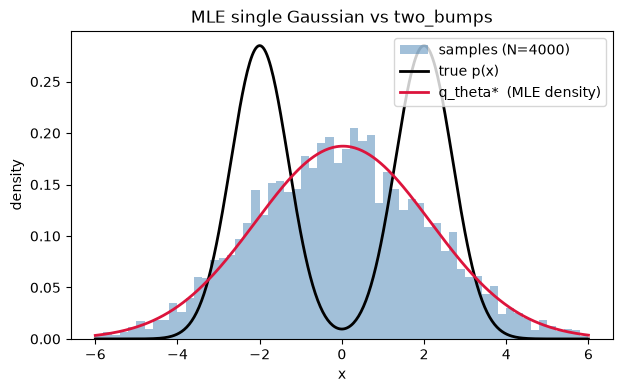

In [2]:
# --- the single-Gaussian family, parametrized by (mu, log_sigma) so sigma>0 is automatic ---
def q_logprob(x, mu, log_sigma):
    sigma = jnp.exp(log_sigma)
    return -0.5*jnp.log(2*jnp.pi) - log_sigma - 0.5*((x - mu)/sigma)**2

# --- closed-form MLE: mu* = mean, sigma* = std (ddof=0 -> the 1/N MLE variance) ---
mu_star    = jnp.mean(data)
sigma_star = jnp.std(data)
print(f"closed-form MLE:   mu* = {mu_star:.4f}    sigma* = {sigma_star:.4f}")

# --- eye test: fitted single Gaussian (crimson) over the true two bumps (black) ---
mle_samples = mu_star + sigma_star*random.normal(random.PRNGKey(1), (4000,))
ax = plot_samples_vs_truth(mle_samples, two_bumps.log_prob,
                           title="MLE single Gaussian vs two_bumps")
grid = jnp.linspace(-6, 6, 400)
ax.plot(grid, jnp.exp(q_logprob(grid, mu_star, jnp.log(sigma_star))),
        color="crimson", lw=2, label="q_theta*  (MLE density)")
ax.legend()

# --- the irreducible gap: how far is the BEST single Gaussian from truth? ---
gK   = jnp.linspace(-8, 8, 4000)
p_pdf = jnp.exp(two_bumps.log_prob(gK))
q_pdf = jnp.exp(q_logprob(gK, mu_star, jnp.log(sigma_star)))
print(f"forward KL(p || q*) = {kl_grid(p_pdf, q_pdf, gK):.4f}   <- irreducible (model is too simple)")
print(f"W1(truth, MLE fit)  = {wasserstein1(two_bumps.sample(random.PRNGKey(2), 4000), mle_samples):.4f}")

## 🤔 CHECKPOINT C1.2 — before the optimizer runs

*Archetype: Predict-then-run.* In §4 we throw away the closed form and minimize $\mathrm{NLL}(\theta)=-\frac1N\sum_i\log q_\theta(x_i)$ with `jax.grad` + Optax Adam, starting from $\mu=0,\ \log\sigma=0$. Predict first:

**C1.2a · The landing spot.** Where do $(\hat\mu,\hat\sigma)$ end up — and *why must* gradient ascent on a strictly-concave objective find the **same** $\theta^*$ as the closed form (no luck, no init-dependence)?

**C1.2b · The loss floor.** Sketch the NLL-vs-step curve: starting value, shape, and the number it flattens toward. Using $\mathrm{NLL}\to H(p)+\mathrm{KL}(p\|q^*)$ with $H(p)\approx1.749$ and the KL you just printed, predict the final loss to 2 decimals.

**C1.2c · The $\sigma>0$ trap. _(Break-it)_** We optimize $\log\sigma$, not $\sigma$. Why? What concretely goes wrong on the very first step if we optimize $\sigma$ directly and Adam pushes it to a negative value — trace it through the $\log\sigma$ and $1/\sigma^2$ terms of the log-density.

### Your answer — C1.2

*(type here, or just answer in chat)*

> C1.2a — it will just converge to maximum gradient ascent or minimum with gradient descent  
>
> C1.2b — so H(p) is just a floor of your loss right you cannot go further down is a lower bound then the final loss will be at max the H(p) no? 
>
> C1.2c —  sigma<0 gives log(sigma) NaN

## 4 · The first training loop — rediscover θ* with no formula

Now pretend we never knew $\mu^*=\bar x$ — because for *every* model after this one, there is no closed form. We minimize $\mathrm{NLL}(\theta)$ with `jax.value_and_grad` (the gradient) + Optax Adam (the steps), starting cold at $\mu=0,\log\sigma=0$, and check we land on the answer key.

> **What are `jax.grad` and Optax doing underneath?** For one notebook we take them on faith. The scheduled **no-magic detour** (right after N1) hand-codes backprop and Adam in pure NumPy so this is never a black box. Today: trust the autodiff, watch the generative idea.

Two things to verify against your C1.2 predictions: the loop lands on $(\mu^*,\sigma^*)$, and the loss flattens at the **crimson** line $H(p)+\mathrm{KL}^*\approx2.17$ — *above* the gray entropy floor $H(p)\approx1.749$, by exactly the misspecification gap.

trained (Adam):  mu_hat = 0.0269   sigma_hat = 2.1302
closed form:     mu*    = 0.0269   sigma*    = 2.1302   <- same point, no formula used
final NLL = 2.1751
H(p) = 1.7492   +   KL* = 0.4204   =   2.1697   <- equals final NLL (the knot)


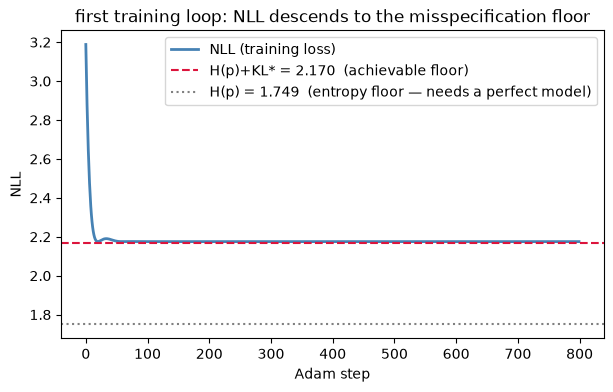

In [3]:
# --- the loss: negative average log-likelihood of the data under q_theta ---
def nll(params):
    return -jnp.mean(q_logprob(data, params["mu"], params["log_sigma"]))

params = {"mu": jnp.array(0.0), "log_sigma": jnp.array(0.0)}   # cold start: q = N(0, 1)
opt = optax.adam(0.05)
state = opt.init(params)
val_and_grad = jax.value_and_grad(nll)

losses = []
for step in range(800):
    loss, grads = val_and_grad(params)
    losses.append(float(loss))
    updates, state = opt.update(grads, state)
    params = optax.apply_updates(params, updates)

mu_hat, sigma_hat = params["mu"], jnp.exp(params["log_sigma"])
print(f"trained (Adam):  mu_hat = {mu_hat:.4f}   sigma_hat = {sigma_hat:.4f}")
print(f"closed form:     mu*    = {mu_star:.4f}   sigma*    = {sigma_star:.4f}   <- same point, no formula used")
print(f"final NLL = {losses[-1]:.4f}")

# --- tie the knot numerically: final NLL == cross-entropy == H(p) + forward KL ---
dxK = gK[1] - gK[0]
Hp     = -jnp.sum(p_pdf * two_bumps.log_prob(gK)) * dxK
q_hat  = jnp.exp(q_logprob(gK, mu_hat, jnp.log(sigma_hat)))
KLstar = kl_grid(p_pdf, q_hat, gK)
print(f"H(p) = {Hp:.4f}   +   KL* = {KLstar:.4f}   =   {Hp + KLstar:.4f}   <- equals final NLL (the knot)")

# --- loss curve with both floors ---
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(losses, color="steelblue", lw=2, label="NLL (training loss)")
ax.axhline(float(Hp + KLstar), color="crimson", ls="--",
           label=f"H(p)+KL* = {float(Hp+KLstar):.3f}  (achievable floor)")
ax.axhline(float(Hp), color="gray", ls=":",
           label=f"H(p) = {float(Hp):.3f}  (entropy floor — needs a perfect model)")
ax.set_xlabel("Adam step"); ax.set_ylabel("NLL")
ax.set_title("first training loop: NLL descends to the misspecification floor")
ax.legend()

## 5 · Keep the family, swap the objective — the mode-seeking twin

MLE minimized *forward* $\mathrm{KL}(p\,\|\,q_\theta)$. What if we point the **same two-knob Gaussian** at the *other* direction — *reverse* $\mathrm{KL}(q_\theta\,\|\,p)$?

$$\mathrm{KL}(q_\theta\,\|\,p)=\mathbb{E}_{x\sim q_\theta}\big[\log q_\theta(x)-\log p(x)\big].$$

Read the subscript carefully: the expectation is now over **$q_\theta$, the model** — not over `p`. We draw $x=\mu+\sigma\varepsilon$ (reparametrize, so the gradient flows through $\mu,\sigma$) and evaluate $\log p(x)$. **That last step needs the formula for `p`** — which we only have because this is toy-land. Hold that thought; one of the checkpoint questions is about why this single fact makes reverse KL untrainable in the real world while MLE sails through.

This is N0's forward-vs-reverse duality, no longer a story about two pre-baked defendants `W` and `N`, but *manufactured on demand from one family by choosing a direction*.

## 🤔 CHECKPOINT C1.3 — predict the twin, then explain the asymmetry

*Archetypes: Predict-then-run + Connect + Break-it.*

**C1.3a · Predict the landing.** Minimizing $\mathrm{KL}(q_\theta\|p)$ over the single Gaussian — does it cover both bumps or snap onto one? If one: which bump, and what breaks the $\pm2$ symmetry? Estimate the resulting $\sigma$ (compare to the bump's own width $0.7$).

**C1.3b · The asymmetry that decides everything. _(Connect)_** MLE (forward KL) trains on samples alone; reverse KL cannot be trained without the formula for `p`. Explain it by pointing at **which distribution each objective's expectation integrates over** — and what that forces you to be able to *evaluate*. (This is exactly why GANs in N5 need a *trick* to chase a reverse-KL-like target without ever writing down `p`.)

**C1.3c · Two ways to blow up. _(Break-it)_** Forward $\mathrm{KL}(p\|q)\to\infty$ under what failure? Reverse $\mathrm{KL}(q\|p)\to\infty$ under what failure? Tag each with *precision* or *recall*, and say which fit (MLE vs reverse) is courting which infinity.

### Your answer — C1.3

*(type here, or just answer in chat)*

> C1.3a — it snaps to one cause it penalizes where penalizes false positives ( where p is low and q is high) so is precision you will only have one bump
> C1.3b — for training on the reverse KL you need to find p(x) at the values from 'q' .. so you need p(x) to evaluate. Penalizes putting data samples where p is low. 
>
> C1.3c — forward KL goes to infinity when q evaluated at the data samples is low while p is high (penalizes false negatives so means high recall). This turns out to be minimizing the NLL negative likelihood of q at the samples of p.
    - The reverse KL goes to infinity when p is low and q is high so it penalizes false positives getting you high precision. This turns out to be just evaluating q and penalizing for the value of that sample evaluated at p 



In [ ]:
# --- reverse KL(q_theta || p): expectation is over the MODEL -> sample x = mu + sigma*eps (reparam) ---
# The integrand needs log p(x). We can only evaluate it because two_bumps is known -- TOY-ONLY.
def reverse_kl(params, eps):
    x = params["mu"] + jnp.exp(params["log_sigma"]) * eps
    return jnp.mean(q_logprob(x, params["mu"], params["log_sigma"]) - two_bumps.log_prob(x))

prm = {"mu": jnp.array(1.0), "log_sigma": jnp.array(0.0)}   # init off-center -> breaks the +/-2 symmetry
opt_r = optax.adam(0.02)
state_r = opt_r.init(prm)
vg_r = jax.value_and_grad(reverse_kl)
kk = random.PRNGKey(7)
for step in range(3000):
    kk, sub = random.split(kk)
    eps = random.normal(sub, (4096,))                       # fresh MC draw each step
    loss_r, grads_r = vg_r(prm, eps)
    updates, state_r = opt_r.update(grads_r, state_r)
    prm = optax.apply_updates(prm, updates)

muR, sigmaR = prm["mu"], jnp.exp(prm["log_sigma"])
print(f"forward / MLE  fit:  N({mu_hat:.3f}, {sigma_hat:.3f})   <- covers BOTH bumps")
print(f"reverse-KL     fit:  N({muR:.3f}, {sigmaR:.3f})   <- snapped onto ONE bump (sigma ~ 0.7)")

# --- side-by-side eye test: same family, two objectives, two personalities ---
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
fwd_s = mu_hat + sigma_hat * random.normal(random.PRNGKey(1), (4000,))
rev_s = muR    + sigmaR    * random.normal(random.PRNGKey(2), (4000,))
plot_samples_vs_truth(fwd_s, two_bumps.log_prob, title="forward KL (MLE): mode-covering", ax=axL)
plot_samples_vs_truth(rev_s, two_bumps.log_prob, title="reverse KL: mode-seeking",      ax=axR)

# --- the duality as a table: each objective crowns its OWN fit ---
print("\n                forwardKL(p||q)   reverseKL(q||p)      W1")
for name, mu, sig in [("forward/MLE", mu_hat, sigma_hat), ("reverse-KL ", muR, sigmaR)]:
    q  = jnp.exp(q_logprob(gK, mu, jnp.log(sig)))
    fkl = kl_grid(p_pdf, q, gK)
    rkl = kl_grid(q, p_pdf, gK)
    sm  = mu + sig * random.normal(random.PRNGKey(13), (4000,))
    w1  = wasserstein1(two_bumps.sample(random.PRNGKey(14), 4000), sm)
    print(f"  {name}      {fkl:6.3f}            {rkl:6.3f}         {w1:5.3f}")

Same two knobs, two objectives, two personalities — and **each KL direction crowns its own fit** (forward picks the spread-out one, reverse picks the one-bump one). N0's punchline, re-derived from *training* instead of from two hand-picked defendants. The asterisk under the whole left column: only **forward / MLE** could have been trained without secretly knowing `p`. The mode-seeking fit on the right is a thing we can *want* but, in the real world, cannot reach by this route — which is the entire reason GANs (N5) exist.

## 🎯 Exit questions — E1 *(self-check)*

**E1.1 · The bedrock chain.** Write the full equality chain linking MLE, NLL, cross-entropy, forward KL, and $\mathbb{E}_p[\log q]$ — and say in one sentence why dropping $-H(p)$ is exactly what lets you train without ever seeing `p`.

**E1.2 · Two floors.** The loss flattened at $\approx2.17$, not $1.749$. Name each number, name the gap between them, and say which number moves (and which doesn't) if you swap the single Gaussian for a 2-component mixture.

**E1.3 · Two roads out of misspecification. _(Connect → N2–N5)_** The single Gaussian's KL floor is $0.42$ because the family is too small. Name the two distinct ways forward: (a) a richer family that *keeps* $\log q$ tractable; (b) a family where $\log q$ goes intractable so you must change the *objective*. Drop at least one upcoming notebook into each road.

**E1.4 · The one denied capability. _(Connect → N0)_** You reproduced N0's forward/reverse split from training alone. What single real-world limitation makes only the *forward* road trainable — and which later family is built to get around it?

### Your answer — E1 *(worked together in chat)*

> **E1.1** — $\arg\min\mathrm{NLL}=\arg\min H(p,q)=\arg\min\mathrm{KL}(p\|q)=\arg\max\mathbb{E}_p[\log q]=\text{MLE}$. The frozen $-H(p)$ is the *only* `p`-needing term and it's an additive constant, so it drops under $\arg\min$ — leaving an objective you estimate from samples alone.
>
> **E1.2** — $1.749=H(p)$, the entropy floor, reachable only by a *perfect* model (KL$=0$). $2.17=H(p)+\mathrm{KL}^*$, the achievable floor for *this* family. The $0.42$ gap is **misspecification**. Swap in a 2-component mixture and $\mathrm{KL}^*$ (hence $2.17$) drops toward the floor; $H(p)=1.749$ never moves (it's a property of the truth, not the model).
>
> **E1.3** — Two roads: **(a) richer family, keep exact $\log q$** → flows N2 (change-of-variables), autoregressive N3 (chain rule); train by plain MLE. **(b) $\log q$ intractable, change the objective** → VAE N4 (obstruction: the $\int dz$ marginal → optimize the ELBO lower bound), GAN N5 (obstruction: non-invertible generator, no density at all → adversarial density-ratio on samples).
>
> **E1.4** — The denied capability is **evaluating the true $p(x)$** (we only ever hold samples of it). Forward KL / MLE is the one road that never asks for it — it only evaluates *our own* $q$ at the data. Reverse-KL / sample-quality objectives need $\log p$ → untrainable directly. **GANs (N5)** are built to route around it: a discriminator estimates the ratio $p/q$ from two sample piles, so no density is ever evaluated.

## 📌 N1 summary — Maximum likelihood = minimizing forward KL

**The shift.** N0 *graded* fixed models; N1 *trains* one. Pick a parametric family $q_\theta=\mathcal{N}(\mu,\sigma^2)$ and search $\theta$ for the member closest to `two_bumps` — with **forward KL** as the target, the same ruler N0 said “MLE minimizes.”

**The bedrock identity.** Split $\mathrm{KL}(p\|q_\theta)=\underbrace{-H(p)}_{\text{frozen, needs }p}-\underbrace{\mathbb{E}_p[\log q_\theta]}_{\text{moving}}$. The frozen $-H(p)$ is an additive constant — it **drops under $\arg\min_\theta$**, and it was the *only* `p`-needing piece. Monte-Carlo the rest with the data:

$$\arg\min_\theta\;\underbrace{-\tfrac1N\textstyle\sum_i\log q_\theta(x_i)}_{\mathrm{NLL}}\;=\;\arg\min H(p,q_\theta)\;=\;\arg\min\mathrm{KL}(p\|q_\theta)\;=\;\arg\max\mathbb{E}_p[\log q_\theta]\;=\;\textbf{MLE}.$$

That dropped constant is the whole reason **MLE trains on samples alone** while the KL *value* (toy-only) still needs `p`.

**The first training loop.** Closed form $\mu^*=\bar x,\ \sigma^{*2}=\tfrac1N\sum(x_i-\mu^*)^2$ gave the answer key $(0.027,\,2.130)$; `jax.value_and_grad` + Optax Adam (params $(\mu,\log\sigma)$ so $\sigma>0$ for free) **rediscovered the same point with no formula** — validating the optimizer we'll lean on for the rest of the course. The knot tied numerically: final $\mathrm{NLL}=2.175\approx H(p,q^*)=H(p)+\mathrm{KL}=1.749+0.421$.

**Two floors.** Loss $\ge H(p)=1.749$ always, but a single Gaussian stalls at $H(p)+\mathrm{KL}^*=2.17$. The $0.42$ gap is **misspecification in loss units** — the family's fault, not the optimizer's.

**Same family, two objectives (N0's duality, re-derived from training):**

| fit | forward KL($p\|q$) | reverse KL($q\|p$) | W1 | personality |
|---|---|---|---|---|
| forward / **MLE** · N(0.03, 2.13) | **0.420** 🏆 | 0.812 | 0.620 | mode-covering / recall (mass in the empty valley) |
| **reverse-KL** · N(1.97, 0.72) | 6.839 | **0.686** 🏆 | 1.957 | mode-seeking / precision (snaps onto one bump) |

Each KL direction crowns its **own** fit. The asymmetry that decides which road is even *open*: forward needs *samples from $p$* (✓ the dataset) + *evaluate $q$* (✓ the model); reverse needs *evaluate $p$* (✗ never available in the real world). **Only forward / MLE is trainable** — the mode-seeking twin is reachable only via N5's GAN density-ratio trick.

**Practical residue (transfers to every model):** the $\log\sigma$ reparam for positive params; reading a loss-floor as *model limit vs optimizer limit*; strict concavity ⇒ init-independence (a luxury that ends at N5). The 2-param Gaussian and a 100M-param diffusion net differ only in the *family*, the *tractability of $\log q$*, and the *sampler* — the loss and its logic are what you built here.

**→ N1b:** drop the parametric family entirely — **histogram & KDE**, the nonparametric baseline, where MLE can drive training KL toward $0$ and the new enemy becomes *overfitting / generalization* (the floor was misspecification; now it's variance). Then **→ N2 normalizing flows:** the first road out — a *rich* family that still hands you exact $\log q$.